In [2]:
import matplotlib.pyplot as plt

cmd_actions shape: (2120, 14)
robot_actions shape: (2120, 14)


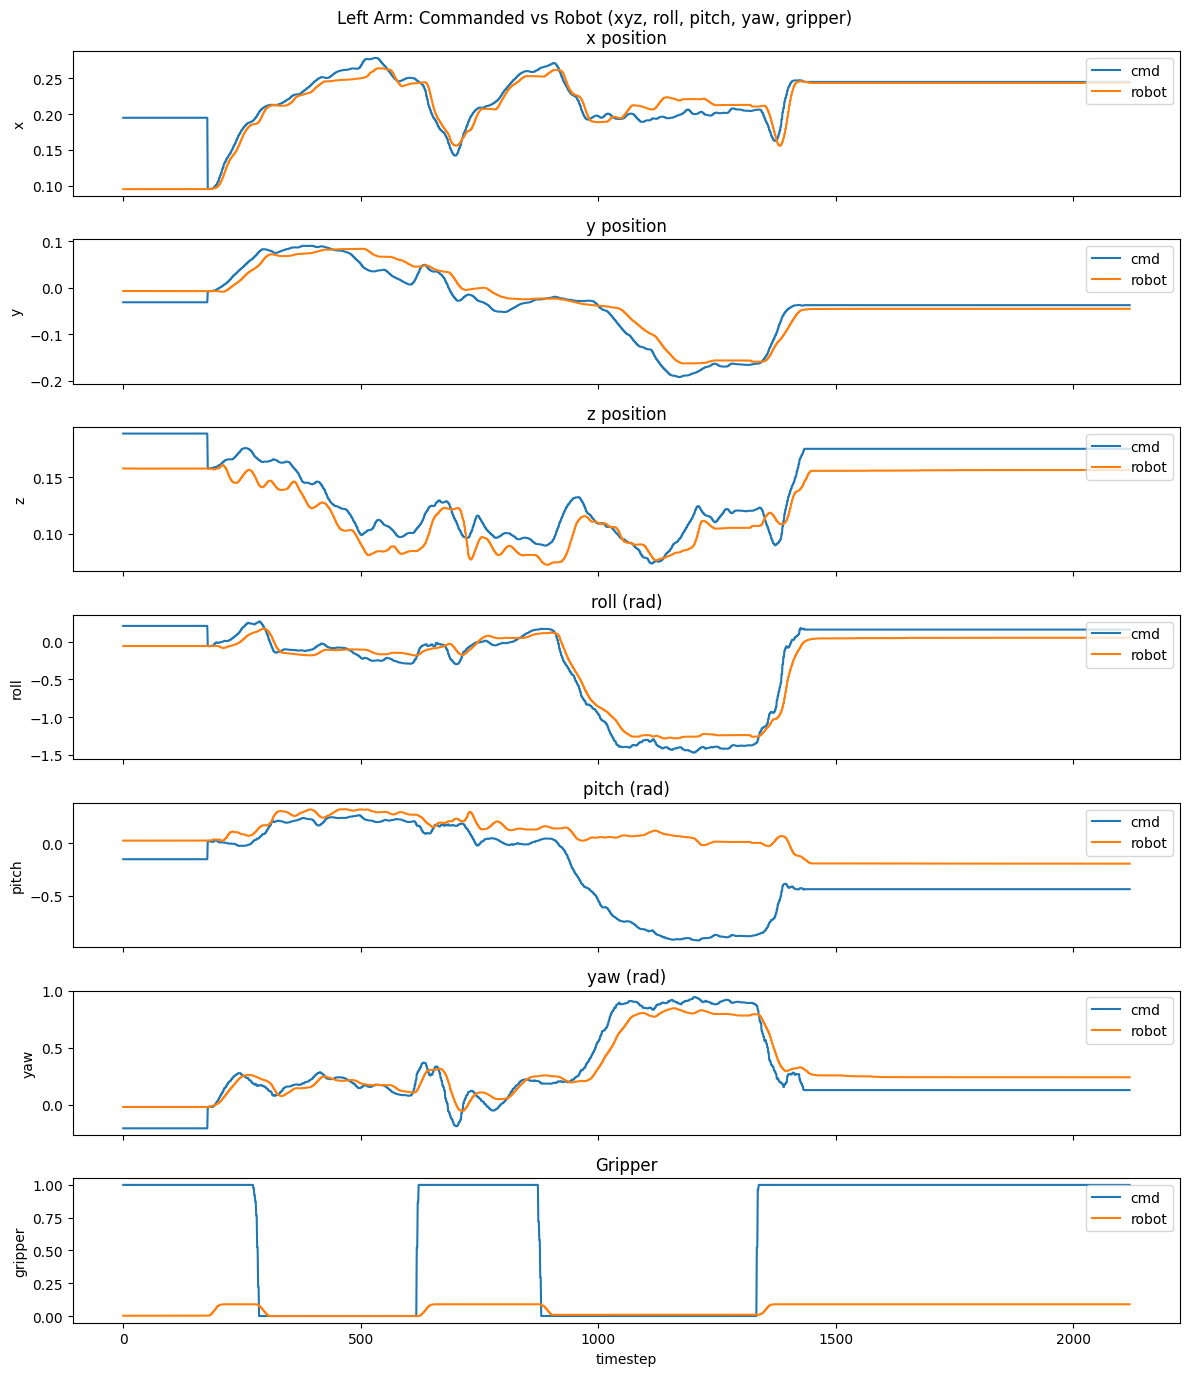

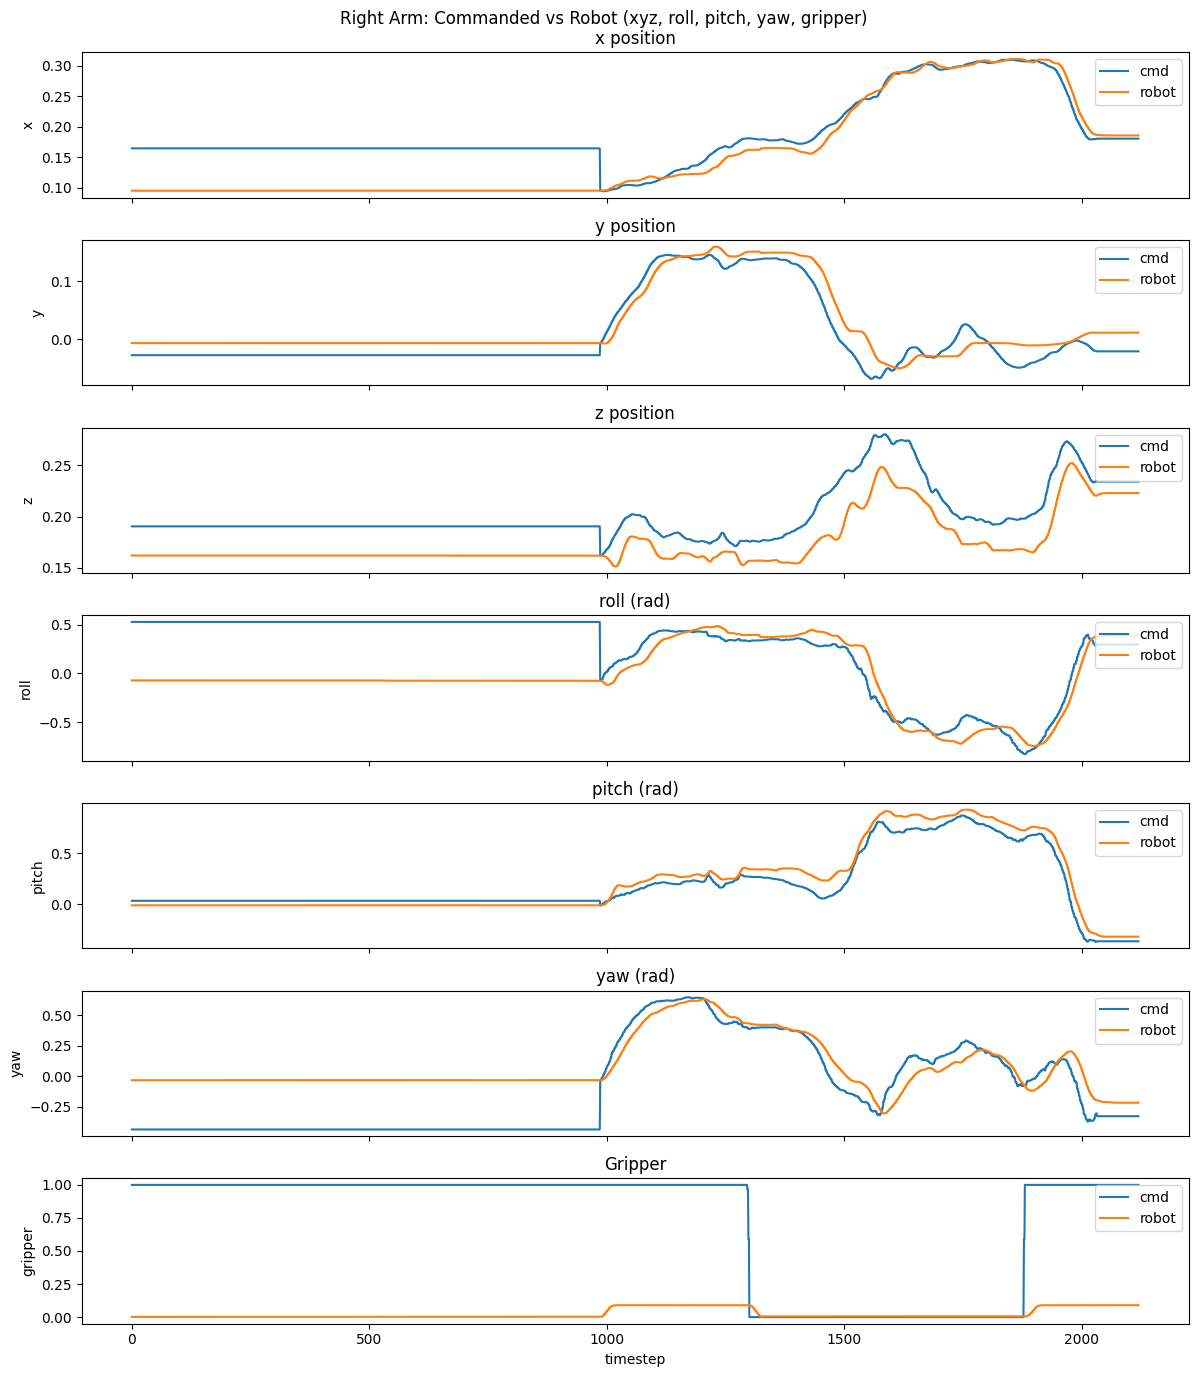

cams: ['front_img_1', 'left_wrist_img', 'right_wrist_img']
front_img_1 shape: (2120, 480, 640, 3)


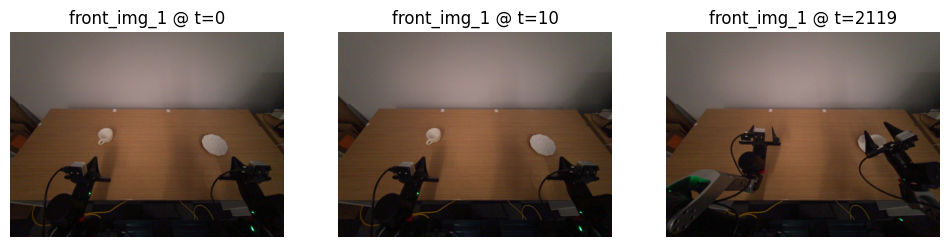

left_wrist_img shape: (2120, 480, 640, 3)


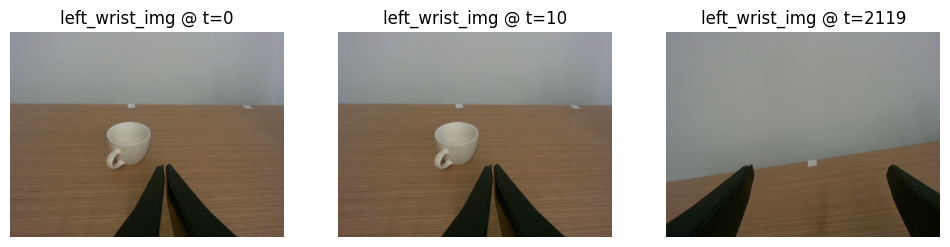

right_wrist_img shape: (2120, 480, 640, 3)


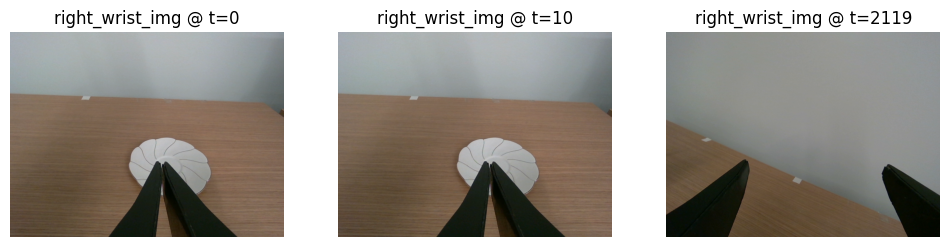

In [11]:
import h5py
import numpy as np

h5_path = "/home/robot/robot_ws/egomimic/robot/demos/white_ceramic_cup_white_saucer/success_demo/demo_8.hdf5"  # <- change this

with h5py.File(h5_path, "r") as f:
    # 1) load action
    cmd_actions = f["actions"]["eepose"][...]  # shape: (T, 14) based on your saver
    robot_actions = f["observations"]["eepose"][...]
    T = cmd_actions.shape[0]
    print("cmd_actions shape:", cmd_actions.shape)
    print("robot_actions shape:", robot_actions.shape)

    # left arm: 0:3 xyz, 3:6 ypr, 13 gripper
    # right arm: 7:10 xyz, 10:13 ypr, 14 gripper

    arms = ["left", "right"]
    dims = ["x", "y", "z", "roll", "pitch", "yaw", "gripper"]
    # index map
    sel = {
        "left": {
            "xyz": slice(0, 3),
            "ypr": slice(3, 6),
            "gripper": 6,
        },
        "right": {
            "xyz": slice(7, 10),
            "ypr": slice(10, 13),
            "gripper": 13,
        },
    }

    # ---- plot for each arm, each variable ---
    for arm in arms:
        fig, axs = plt.subplots(7, 1, figsize=(12, 14), sharex=True)
        fig.suptitle(
            f"{arm.capitalize()} Arm: Commanded vs Robot (xyz, roll, pitch, yaw, gripper)"
        )

        # xyz
        for i, label in enumerate(["x", "y", "z"]):
            axs[i].plot(
                np.arange(T), cmd_actions[:, sel[arm]["xyz"].start + i], label="cmd"
            )
            axs[i].plot(
                np.arange(T), robot_actions[:, sel[arm]["xyz"].start + i], label="robot"
            )
            axs[i].set_ylabel(label)
            axs[i].legend(loc="upper right")
            axs[i].set_title(f"{label} position")

        # roll, pitch, yaw (note: these are YPR, so roll=y, pitch=p, yaw=r)
        for j, label in enumerate(["roll", "pitch", "yaw"]):
            axs[3 + j].plot(
                np.arange(T), cmd_actions[:, sel[arm]["ypr"].start + j], label="cmd"
            )
            axs[3 + j].plot(
                np.arange(T), robot_actions[:, sel[arm]["ypr"].start + j], label="robot"
            )
            axs[3 + j].set_ylabel(label)
            axs[3 + j].legend(loc="upper right")
            axs[3 + j].set_title(f"{label} (rad)")

        # gripper
        axs[6].plot(np.arange(T), cmd_actions[:, sel[arm]["gripper"]], label="cmd")
        axs[6].plot(np.arange(T), robot_actions[:, sel[arm]["gripper"]], label="robot")
        axs[6].set_ylabel("gripper")
        axs[6].legend(loc="upper right")
        axs[6].set_title("Gripper")

        axs[-1].set_xlabel("timestep")
        plt.tight_layout()
        plt.show()

    # ---- show images ----
    cam_group = f["observations"]["images"]
    cam_names = list(cam_group.keys())
    print("cams:", cam_names)

    # 3) sample a few timesteps to show images
    timesteps_to_show = [0, min(10, T - 1), T - 1]  # first, 10th, last

    for cam in cam_names:
        imgs = cam_group[cam]  # (T, 480, 640, 3)
        print(f"{cam} shape:", imgs.shape)

        fig, axs = plt.subplots(
            1, len(timesteps_to_show), figsize=(4 * len(timesteps_to_show), 4)
        )
        if len(timesteps_to_show) == 1:
            axs = [axs]
        for j, t in enumerate(timesteps_to_show):
            axs[j].imshow(imgs[t])
            axs[j].set_title(f"{cam} @ t={t}")
            axs[j].axis("off")
        plt.show()

In [ ]:
import os

import h5py
from PIL import Image  # pillow

h5_path = "/home/robot/robot_ws/egomimic/robot/demos/demo_1.hdf5"  # change
out_dir = "./frames"
os.makedirs(out_dir, exist_ok=True)

with h5py.File(h5_path, "r") as f:
    img_grp = f["observations"]["images"]
    cam_names = list(img_grp.keys())
    print("cams:", cam_names)

    for cam in cam_names:
        frames = img_grp[cam]  # (T, H, W, 3), uint8, RGB
        T = frames.shape[0]
        for i in range(T):
            rgb = frames[i]  # numpy array
            img = Image.fromarray(rgb)  # RGB already
            fname = os.path.join(out_dir, f"{cam}_{i:05d}.png")
            img.save(fname)

print(f"saved frames to {out_dir}")

In [3]:
# Corrected action visualization and saving
import os

import h5py
import numpy as np
import torch
import torchvision.io as io

from egomimic.utils.egomimicUtils import CameraTransforms

h5_path = "/home/robot/robot_ws/egomimic/robot/demos/white_cup_white_saucer/success_demo/demo_0.hdf5"
save_dir = "./visualization/"
os.makedirs(save_dir, exist_ok=True)

camera_transforms = CameraTransforms(intrinsics_key="base", extrinsics_key="x5Dec13_1")
arm ="right"
start_index = 0 if arm == "left" else 7

with h5py.File(h5_path, "r") as f:
    images = f["observations"]["images"]["front_img_1"]          # (T, H, W, 3) uint8 RGB
    actions = f["action"]  # (T, 3)
    every_nth = 15
    nth_image = images[::every_nth]
    for i, im in enumerate(nth_image):
        # Build batch of size 1 for visualize_actions
        action_seq = actions[i * every_nth : min(i * every_nth + 100, actions.shape[0])]                   # (1, 3)

        im_viz = visualize_actions(
            im,
            action_seq,
            camera_transforms.extrinsics,
            camera_transforms.intrinsics,
            arm=arm,
        )
        # Save the visualized image
        img_tensor = torch.from_numpy(im_viz).permute(2, 0, 1).contiguous()
        io.write_png(img_tensor, os.path.join(save_dir, f"image_{i * every_nth}.png"))

        print(f"Saved image {i * every_nth} with overlays to {save_dir}")


ModuleNotFoundError: No module named 'egomimic'

In [ ]:
# Corrected action visualization and saving
import os

import h5py
import numpy as np
import torch
import torchvision.io as io
from matplotlib import pyplot as plt

from egomimic.utils.egomimicUtils import CameraTransforms

h5_path = "/home/robot/robot_ws/egomimic/robot/demos/aws/1764443911411.hdf5"
save_dir = "./visualization/"
os.makedirs(save_dir, exist_ok=True)

camera_transforms = CameraTransforms(intrinsics_key="base", extrinsics_key="x5Dec13_1")
arm ="right"
start_index = 0 if arm == "left" else 7

with h5py.File(h5_path, "r") as f:
    images = f["observations"]["images"]["front_img_1"]          # (T, H, W, 3) uint8 RGB
    actions = f["action"]  # (T, 3)

    action_seq = actions[0][None, ]                  # (1, 3)
    im = images[0]
    im_viz = visualize_actions(
        im,
        action_seq,
        camera_transforms.extrinsics,
        camera_transforms.intrinsics,
        arm=arm,
    )
    # Save the visualized image
    img_tensor = torch.from_numpy(im_viz).permute(2, 0, 1).contiguous()
    plt.imshow(im_viz)


In [ ]:

import numpy as np
import torch
import torchvision.io as io

from egomimic.robot.eva.eva_kinematics import EvaMinkKinematicsSolver
from egomimic.utils.egomimicUtils import CameraTransforms, draw_actions

kinematics_solver = EvaMinkKinematicsSolver(model_path="/home/robot/robot_ws/egomimic/resources/model_x5.xml")

def visualize_actions(ims, actions, extrinsics, intrinsics, arm="both"):
    if actions.shape[-1] == 7 or actions.shape[-1] == 14:
        ac_type = "joints"
    elif actions.shape[-1] == 3 or actions.shape[-1] == 6:
        ac_type = "xyz"
    else:
        raise ValueError(f"Unknown action type with shape {actions.shape}")
    print(arm)
    ims = draw_actions(
        ims, ac_type, "Purples", actions, extrinsics, intrinsics, arm=arm, kinematics_solver=kinematics_solver
    )

    return ims

In [ ]:
# HDF5 -> overlay (every_nth) -> 30fps MP4 (matches your loop exactly)

import os

import h5py
import torch
import torchvision.io as io

from egomimic.utils.egomimicUtils import CameraTransforms

h5_path ="/home/robot/robot_ws/egomimic/robot/demos/aws/1764457069001.hdf5"
save_dir = "./visualization/"
os.makedirs(save_dir, exist_ok=True)

camera_transforms = CameraTransforms(intrinsics_key="base", extrinsics_key="x5Dec13_2")
print(camera_transforms.extrinsics)
arm = "right"
start_index = 0 if arm == "left" else 7  # unused since you're using f["action"]

every_nth = 1
fps = 30
out_path = os.path.join(save_dir, f"overlay_every{every_nth}_{fps}fps.mp4")

frames = []  # list of (H,W,3) uint8 tensors

with h5py.File(h5_path, "r") as f:
  images = f["observations"]["images"]["front_img_1"]  # (T,H,W,3) uint8 RGB
  actions = f["action"]                                # (T, ?)

  T = images.shape[0]
  for t in range(0, T, every_nth):
    im = images[t]
    action_seq = actions[t : min(t + 100, actions.shape[0])]

    im_viz = visualize_actions(
      im,
      action_seq,
      camera_transforms.extrinsics,
      camera_transforms.intrinsics,
      arm=arm,
    )  # numpy (H,W,3) uint8

    frame = torch.from_numpy(im_viz)
    if frame.dtype != torch.uint8:
      frame = frame.to(torch.uint8)
    frames.append(frame.contiguous())  # (H,W,3)

video = torch.stack(frames, dim=0)  # (T',H,W,3) uint8
io.write_video(out_path, video, fps=fps, video_codec="h264")
print(f"Wrote {video.shape[0]} frames -> {out_path}")
